# Train Time-As-Channels 3D CNN

This notebook intentionally keeps orchestration thin. Split preparation, fitting, reporting, plotting, and persistence are delegated to shared utilities in `src.ml`.


In [14]:
%load_ext autoreload
%autoreload 2

from dataclasses import asdict
from pathlib import Path

import pandas as pd

from src.ml import (
    LossWeightConfig,
    OptimizationConfig,
    display_experiment_summary,
    display_holdout_evaluation,
    fit_estimator_on_experiment,
    persist_experiment_artifacts,
    plot_holdout_branch_embedding_projections,
    plot_training_history,
    prepare_multitask_experiment_data,
)
from src.dataset_config import load_current_dataset_artifact_path
from src.tensor_utils import build_tensor_embedding_2d, load_labeled_tensor_dataset, plot_tensor_embedding_2d

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", None)
pd.set_option("display.expand_frame_repr", False)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [15]:
from src.ml import TimeChannel3DCNNClassifier, TimeChannel3DCNNConfig


In [16]:
# User inputs

dataset_artifact_path = load_current_dataset_artifact_path()
print(dataset_artifact_path.name)
experiment_output_dir = Path("artifacts/nb6_time_channel_3dcnn")
persist_artifacts = True

holdout_fraction = 0.25
validation_fraction_within_train = 0.20
train_num_random_rotations = 8
rotation_range_degrees = 15.0

model_config = TimeChannel3DCNNConfig(
    conv_channels=(8, 16, 24, 32),
    kernel_size_z=(1, 1, 1, 1),
    kernel_size_xy=(5, 3, 3, 3),
    stride_z=(1, 1, 1, 1),
    stride_xy=(1, 1, 1, 1),
    pool_kernel_z=(1, 1, 1, 1),
    pool_kernel_xy=(2, 2, 2, 2),
    pool_stride_z=(1, 1, 1, 1),
    pool_stride_xy=(2, 2, 2, 2),
    embedding_dim=24,
    dropout=0.55,
)
optimization_config = OptimizationConfig(
    batch_size=8,
    epochs=100,
    learning_rate=1e-4,
    weight_decay=5e-3,
    early_stopping_patience=8,
    early_stopping_min_delta=1e-3,
    scheduler_patience=2,
    scheduler_factor=0.7,
    scheduler_min_lr=1e-6,
    validation_split=0.0,
    random_state=0,
    standardize=True,
    device=None,
    verbose=True,
)
loss_weight_config = LossWeightConfig(
    action_weight=1.0,
    compound_weight=0.1,
    concentration_weight=0.05,
)


moa_GA_An_NM_Ac_AC_In_mA_Ag_c2_mca3_mtc16_t20_z5_y64_x64.pt


In [17]:
dataset = load_labeled_tensor_dataset(dataset_artifact_path)


In [18]:
experiment = prepare_multitask_experiment_data(
    dataset,
    holdout_fraction=holdout_fraction,
    validation_fraction_within_train=validation_fraction_within_train,
    train_num_random_rotations=train_num_random_rotations,
    rotation_range_degrees=rotation_range_degrees,
    random_state=optimization_config.random_state,
)


In [19]:
display_experiment_summary(experiment)


,split,n_samples
0,train_augmented,1503
1,train_base,167
2,val,42
3,holdout,70


,mechanism_of_action,compound,concentration_band,n_samples
0,GABAAR_Antagonist,Bemegride,control,63
1,GABAAR_Antagonist,Gabazine,high,63
2,GABAAR_Antagonist,Gabazine,control,54
3,NMDAR_Activation,Cis-ACPD,control,54
4,AChE_Inhibitor_Reversible,Galantamine,high,54
5,mAChR_Agonist_NonSelective,Bethanechol,high,54
6,mAChR_Agonist_NonSelective,Bethanechol,mid,54
7,GABAAR_Antagonist,Bicuculline,mid,45
8,NMDAR_Activation,Cis-ACPD,mid,45
9,NMDAR_Activation,N-methyl-D-aspartate,high,45


In [20]:
model = TimeChannel3DCNNClassifier(
    model_config=model_config,
    optimization_config=optimization_config,
    loss_weight_config=loss_weight_config,
)


In [21]:
fit_estimator_on_experiment(model, experiment)


cols:
    ep=epoch
    lr=learning_rate
    eta=estimated_time_remaining
    trL=train_loss
    trA=train_action_loss
    trCC=train_commutative_consistency_loss
    trFA=train_feature_alignment_loss
    trCo=train_compound_loss
    trCn=train_concentration_loss
    vaL=val_loss
    vaA=val_action_loss
    vaCC=val_commutative_consistency_loss
    vaFA=val_feature_alignment_loss
    vaCo=val_compound_loss
    vaCn=val_concentration_loss
     ep       lr       eta |      trL      trA     trCC     trFA     trCo     trCn |      vaL      vaA     vaCC     vaFA     vaCo     vaCn
001/100 1.00e-04     12:11 |   1.9132   1.5967        -        -   2.6007   1.1280 |   1.8596   1.5501        -        -   2.5365   1.1157
002/100 1.00e-04     11:58 |   1.8496   1.5397        -        -   2.5441   1.1105 |   1.8075   1.5045        -        -   2.4806   1.0996
003/100 1.00e-04     13:09 |   1.7837   1.4811        -        -   2.4735   1.1044 |   1.7546   1.4610        -        -   2.3924   1.0862
004

,conv_channels,"(8, ...)"
,kernel_size_z,"(1, ...)"
,kernel_size_xy,"(5, ...)"
,stride_z,"(1, ...)"
,stride_xy,"(1, ...)"
,pool_kernel_z,"(1, ...)"
,pool_kernel_xy,"(2, ...)"
,pool_stride_z,"(1, ...)"
,pool_stride_xy,"(2, ...)"
,embedding_dim,24
,dropout,0.55


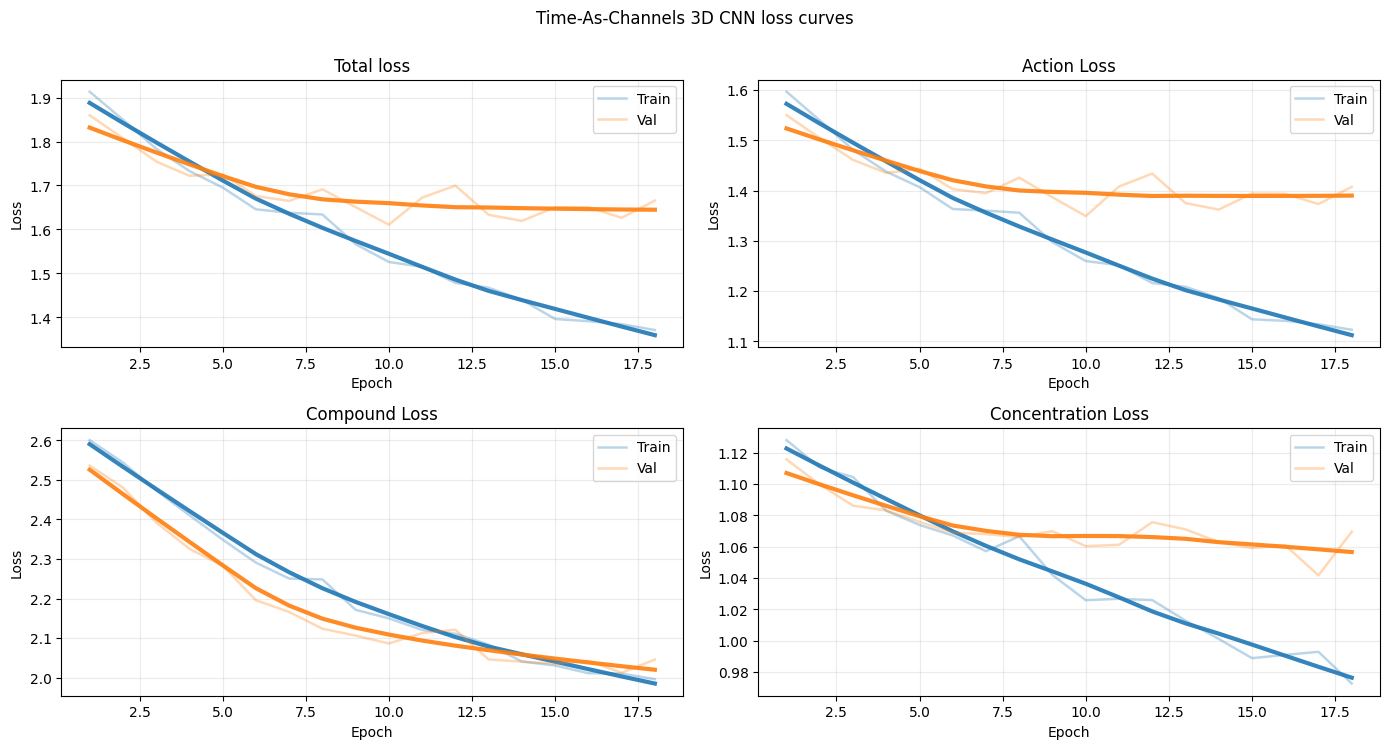

In [22]:
plot_training_history(model, title="Time-As-Channels 3D CNN loss curves", loess_frac=0.6);



## Holdout report: action


,precision,recall,f1-score,support
class,,,,
Water,0.387755,0.791667,0.520548,24.0
GABAAR_Antagonist,0.750000,0.250000,0.375000,12.0
NMDAR_Activation,0.727273,0.800000,0.761905,10.0
AChE_Inhibitor_Reversible,0.000000,0.000000,0.000000,12.0
mAChR_Agonist_NonSelective,0.333333,0.083333,0.133333,12.0


,value
accuracy,0.442857
macro_precision,0.439672
macro_recall,0.385000
macro_f1,0.358157
weighted_precision,0.422555
weighted_recall,0.442857
weighted_f1,0.374460
n_samples,70.000000
roc_auc_ovr_macro,0.691811
average_precision_macro,0.384673


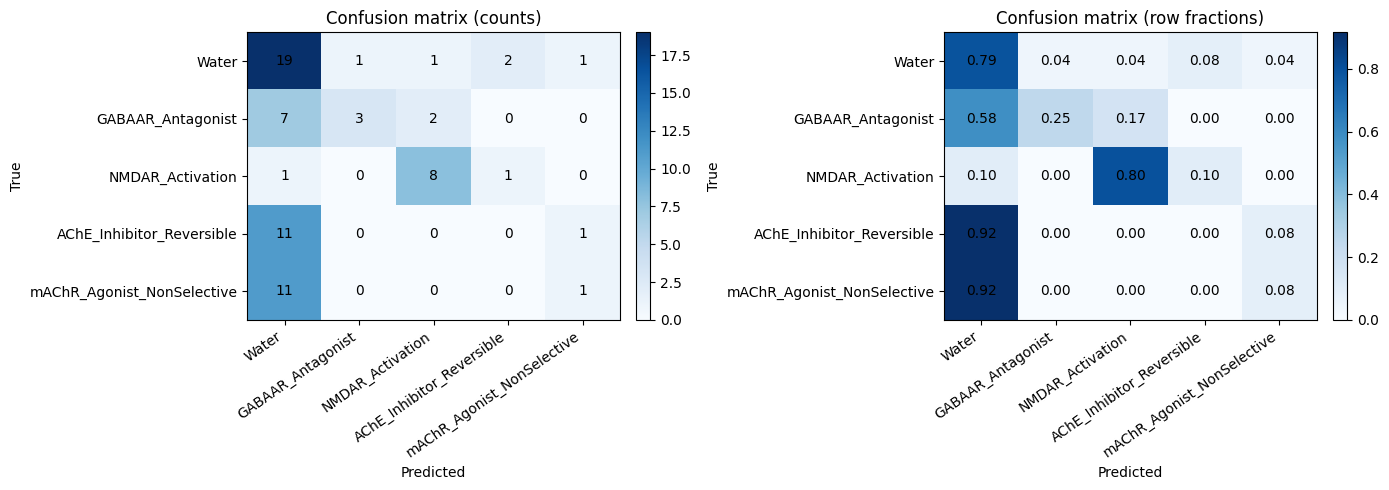


## Holdout report: compound


,precision,recall,f1-score,support
class,,,,
Control,0.40,1.0,0.571429,24.0
Bemegride,0.00,0.0,0.000000,6.0
Bicuculline,0.00,0.0,0.000000,3.0
Gabazine,0.00,0.0,0.000000,3.0
(RS)-(Tetrazol-5-yl)glycine,0.00,0.0,0.000000,3.0
Cis-ACPD,0.00,0.0,0.000000,3.0
N-methyl-D-aspartate,0.25,0.5,0.333333,4.0
Donepezil,0.00,0.0,0.000000,4.0
Galantamine,0.00,0.0,0.000000,4.0


,value
accuracy,0.371429
macro_precision,0.050000
macro_recall,0.115385
macro_f1,0.069597
weighted_precision,0.151429
weighted_recall,0.371429
weighted_f1,0.214966
n_samples,70.000000
roc_auc_ovr_macro,0.672590
average_precision_macro,0.190359


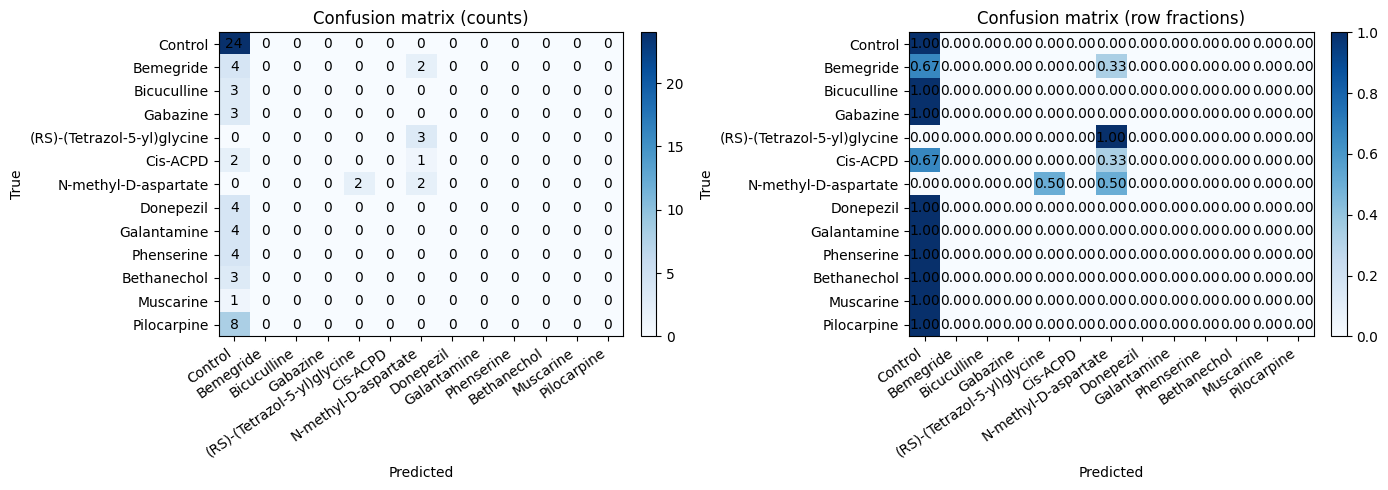


## Holdout report: concentration


,precision,recall,f1-score,support
class,,,,
control,0.404255,0.791667,0.535211,24.0
high,0.434783,0.400000,0.416667,25.0
mid,0.000000,0.000000,0.000000,21.0


,value
accuracy,0.414286
macro_precision,0.279679
macro_recall,0.397222
macro_f1,0.317293
weighted_precision,0.293881
weighted_recall,0.414286
weighted_f1,0.332311
n_samples,70.000000
roc_auc_ovr_macro,0.520713
average_precision_macro,0.376137


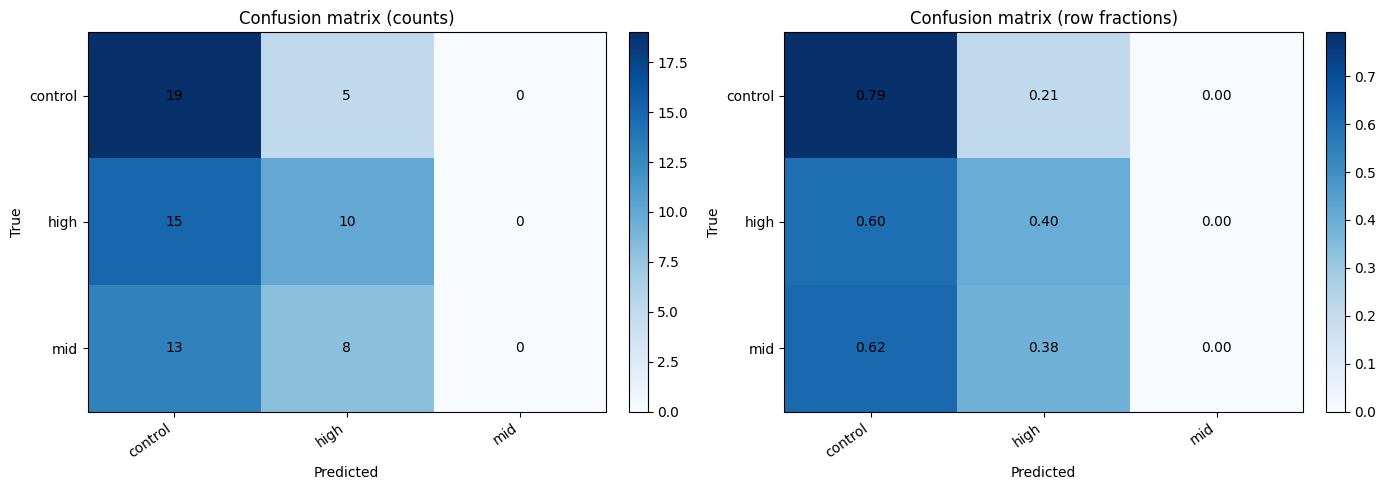

In [23]:
holdout_evaluation = display_holdout_evaluation(model, experiment)


/home/fabrizio/.venvs/py313/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


(<Figure size 1550x1050 with 1 Axes>,
 <Axes: title={'center': 'Holdout embedding projection by action'}, xlabel='Component 1', ylabel='Component 2'>)

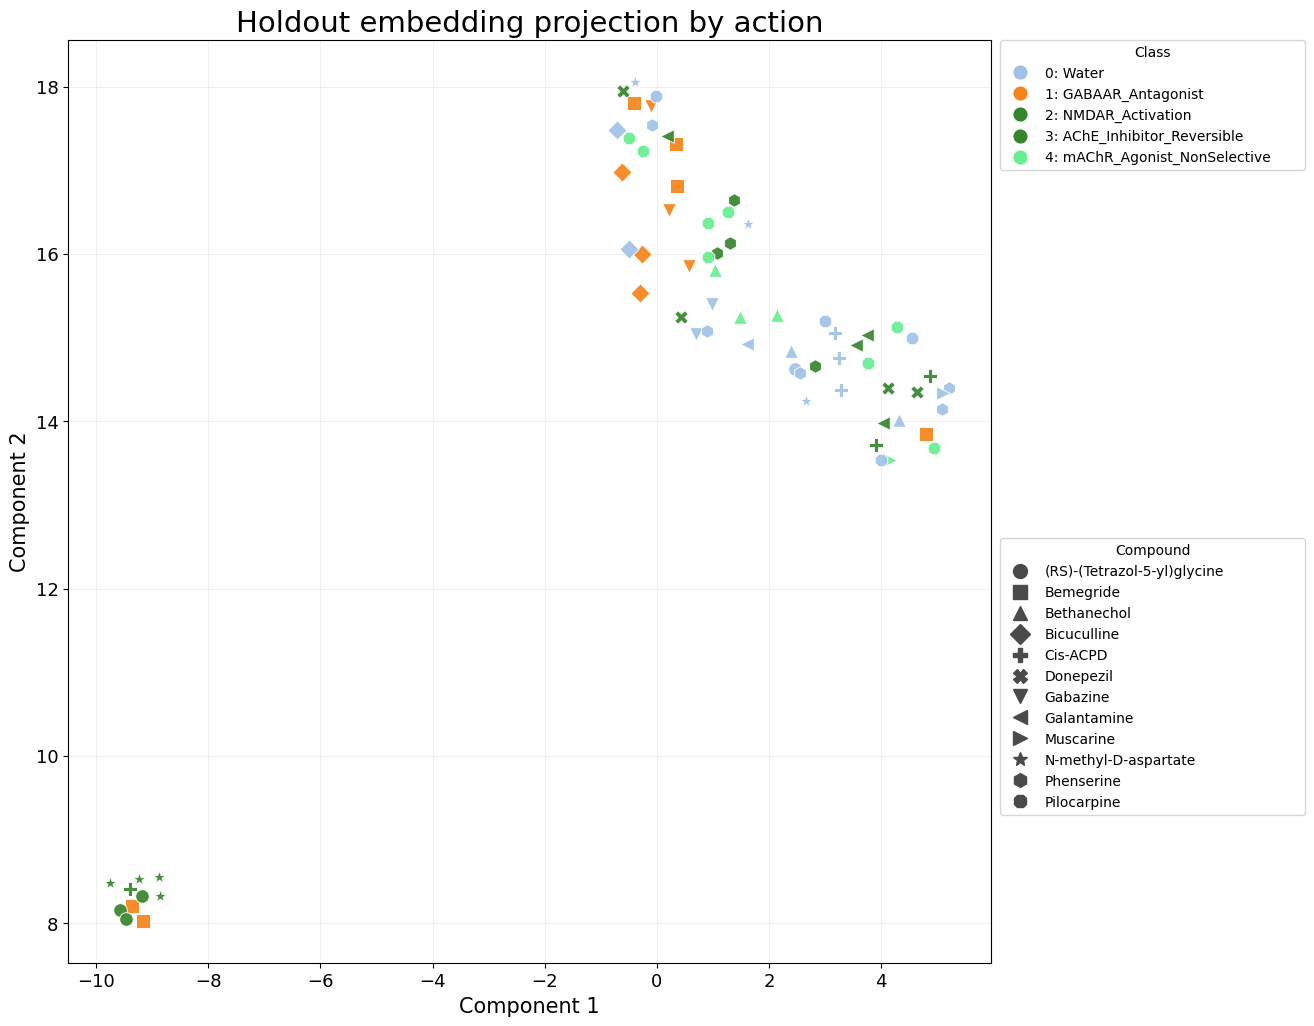

In [27]:
holdout_embedding_projection = build_tensor_embedding_2d(
    model.transform(experiment.splits.X_holdout),
    experiment.y_true_holdout["action"],
    label_map=experiment.label_maps["action"],
    metadata=experiment.splits.metadata_holdout,
    method="umap",
    random_state=optimization_config.random_state,
)
plot_tensor_embedding_2d(
    holdout_embedding_projection,
    title="Holdout embedding projection by action",
    marker_column="compound",
)


In [25]:
run_config = {
    "dataset_artifact_path": dataset_artifact_path,
    "holdout_fraction": holdout_fraction,
    "validation_fraction_within_train": validation_fraction_within_train,
    "train_num_random_rotations": train_num_random_rotations,
    "rotation_range_degrees": rotation_range_degrees,
    "model_config": asdict(model_config),
    "optimization_config": asdict(optimization_config),
    "loss_weight_config": asdict(loss_weight_config),
}


In [26]:
if persist_artifacts:
    experiment_artifacts = persist_experiment_artifacts(
        output_dir=experiment_output_dir,
        estimator=model,
        reports=holdout_evaluation.reports,
        config=run_config,
    )
